# HMDB51 - Classificazione video con TensorFlow

Notebook completo per il progetto HMDB51: prepara gli split ufficiali, legge i clip `.avi`, costruisce un modello TensorFlow/Keras, esegue training, valutazione e predizione su un singolo video.


In [ ]:
from pathlib import Path
import json 
import random
import shutil 
import sys 
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / 'Desktop' / 'Deep Learning ' / 'HMDB project',
    Path('/Users/linshenhao/Desktop/Deep Learning /HMDB project').resolve(),
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / 'scripts').exists() and (candidate / 'dataset').exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Non trovo la cartella progetto con scripts/ e dataset/.')

# I moduli .py stanno tutti in scripts/ (niente piu' package src/hmdb_classifier)
sys.path.insert(0, str(PROJECT_ROOT / 'scripts')) 

from prepare_dataset import build_manifests 
from data import make_dataset, read_class_names, read_manifest
from models import build_model, smoothed_sparse_ce, unfreeze_backbone
from metrics import (
    evaluate_to_dir, plot_training_history,
    plot_confusion_matrix, plot_per_class_accuracy, plot_top_confusions,
)
from video_io import decode_video

print('Project root:', PROJECT_ROOT)
print('TensorFlow:', tf.__version__)

## 2. Parametri del progetto

Training a **due fasi** + regolarizzazione, per battere overfitting/underfitting:

- **FASE A** (`LR_HEAD=1e-3`): backbone congelato, alleno solo la testa GRU + classificatore.
- **FASE B** (`LR_FINETUNE=3e-5`, `FINETUNE_FROM_BLOCK`): sblocco PARZIALE del backbone (solo ultimi blocchi, BatchNorm in inference) per adattare le feature alle azioni.
- **Label smoothing** (`LABEL_SMOOTHING=0.1`) contro l'overconfidence; LR ridotto in base a `val_accuracy` (coerente con early-stopping/checkpoint).

Per una prova rapida imposta `QUICK_LIMIT_PER_CLASS = 2` e poche epoche. Per `mobilenet_gru`: `IMAGE_SIZE = 160`, `FRAMES = 16`, `WEIGHTS = 'imagenet'`.


In [ ]:
DATA_ROOT = PROJECT_ROOT / 'dataset' / 'hmdb51'
SPLITS_ROOT = PROJECT_ROOT / 'dataset' / 'testTrainMulti_7030_splits'
MANIFEST_DIR = PROJECT_ROOT / 'dataset' / 'manifests'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

SPLIT_ID = 1
VAL_RATIO = 0.15
SEED = 42

MODEL_NAME = 'mobilenet_gru'   # 'mobilenet_gru', 'mobilenet_avg', oppure 'conv3d'
WEIGHTS = 'imagenet'           # usa 'none' per evitare il download dei pesi, altrimenti 'imagenet' per i pesi pre-addestrati su ImageNet
DROPOUT = 0.5
LABEL_SMOOTHING = 0.1   # contro l'overconfidence (val_loss che sale mentre val_acc e' stabile)

FRAMES = 16             # numero di frame da estrarre da ogni video
IMAGE_SIZE = 160        # dimensione nativa MobileNetV2 (valide: 96/128/160/192/224)
BATCH_SIZE = 8          # dipende dalla RAM della GPU
QUICK_LIMIT_PER_CLASS = None    # esempio: 2 per una prova molto veloce (None = tutti i video)
CACHE_DATASET = False           # True solo se hai abbastanza RAM

# --- Training a due fasi (transfer learning + fine-tuning) ---
# FASE A: backbone MobileNetV2 CONGELATO, alleno solo testa GRU + classificatore.
#         Le feature ImageNet restano fisse: la testa impara a combinarle.
# FASE B: SBLOCCO il backbone (BatchNorm in inference) e affino con LR basso,
#         cosi' le feature si adattano alle azioni HMDB51. E' questo che alza
#         la val accuracy oltre il tetto del solo transfer learning.
EPOCHS_HEAD = 20            # epoche Fase A (testa)
LR_HEAD = 1e-3             # LR Fase A
DO_FINETUNE = True         # True per eseguire anche la Fase B di fine-tuning
EPOCHS_FINETUNE = 15       # epoche Fase B (fine-tuning)
LR_FINETUNE = 3e-5         # LR Fase B: piu' incisivo del precedente 1e-5, ma sempre basso
FINETUNE_FROM_BLOCK = 'block_11'   # sblocco PARZIALE: solo dagli ultimi blocchi (None = tutto il backbone)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## 3. Verifica del dataset

Controlliamo che HMDB51 sia estratto: deve contenere 51 classi e 6766 video.


In [3]:
class_dirs = sorted(path for path in DATA_ROOT.iterdir() if path.is_dir())
video_paths = sorted(DATA_ROOT.glob('*/*.avi'))

print('Numero classi:', len(class_dirs))
print('Numero video:', len(video_paths))
print('Prime 10 classi:', [path.name for path in class_dirs[:10]])


Numero classi: 51
Numero video: 6754
Prime 10 classi: ['brush_hair', 'cartwheel', 'catch', 'chew', 'clap', 'climb', 'climb_stairs', 'dive', 'draw_sword', 'dribble']


## 4. Generazione dei manifest train/validation/test

Gli split ufficiali HMDB51 usano questi valori nei file `.txt`: `1 = train`, `2 = test`, `0 = unused`. La validation viene ricavata in modo stratificato dal training set ufficiale.


In [ ]:
# Costruisco i manifesti (train/val/test) a partire dai file di split
summary = build_manifests(
    data_root=DATA_ROOT,
    splits_root=SPLITS_ROOT,
    manifest_dir=MANIFEST_DIR,
    split_id=SPLIT_ID,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

print(json.dumps(summary['counts'], indent=2))
print('Manifest directory:', MANIFEST_DIR)


{
  "official": {
    "train": 3518,
    "unused": 1659,
    "test": 1511
  },
  "generated": {
    "train": 3029,
    "val": 489,
    "test": 1511,
    "unused": 1659
  },
  "classes": 51,
  "missing_files": 78,
  "total_existing_in_split_files": 6688
}
Manifest directory: /Users/linshenhao/Desktop/Deep Learning /HMDB project/data/manifests


In [5]:
CLASSES_PATH = MANIFEST_DIR / 'classes.txt'
TRAIN_MANIFEST = MANIFEST_DIR / f'split{SPLIT_ID}_train.csv'
VAL_MANIFEST = MANIFEST_DIR / f'split{SPLIT_ID}_val.csv'
TEST_MANIFEST = MANIFEST_DIR / f'split{SPLIT_ID}_test.csv'

class_names = read_class_names(CLASSES_PATH)
train_records = read_manifest(TRAIN_MANIFEST, limit_per_class=QUICK_LIMIT_PER_CLASS, seed=SEED)
val_records = read_manifest(VAL_MANIFEST, limit_per_class=QUICK_LIMIT_PER_CLASS, seed=SEED)
test_records = read_manifest(TEST_MANIFEST, limit_per_class=QUICK_LIMIT_PER_CLASS, seed=SEED)

print('Classi:', len(class_names))
print('Train:', len(train_records))
print('Validation:', len(val_records))
print('Test:', len(test_records))
print('Esempio record:', train_records[0])


Classi: 51
Train: 3029
Validation: 489
Test: 1511
Esempio record: {'path': '/Users/linshenhao/Desktop/Deep Learning /HMDB project/hmdb51/sit/HP_PRISONER_OF_AZKABAN_sit_f_cm_np1_fr_med_20.avi', 'label': 37, 'class_name': 'sit', 'subset': 'train'}


## 5. Anteprima di un clip

Questa cella legge un video `.avi`, campiona alcuni frame e li mostra. Serve anche come controllo pratico della pipeline OpenCV.


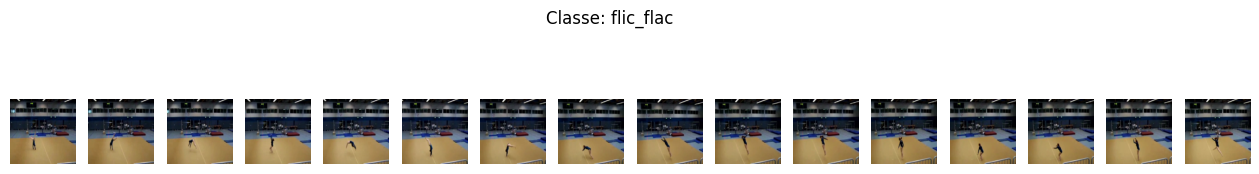

In [ ]:
sample = random.choice(train_records)
video = decode_video(sample['path'], frame_count=16, image_size=128)



# Visualizzo i 16 frame estratti dal video
fig, axes = plt.subplots(1, 16, figsize=(16, 2.2))
for index, ax in enumerate(axes):
    ax.imshow(video[index])
    ax.axis('off')
fig.suptitle(f"Classe: {sample['class_name']}", y=1.05)
plt.show()


## 6. Dataset TensorFlow

Creiamo `tf.data.Dataset` per training e validation. Ogni elemento ha forma `[frames, image_size, image_size, 3]`.


In [ ]:
# Creo i dataset TensorFlow a partire dai manifesti
train_ds, train_count = make_dataset(
    TRAIN_MANIFEST,
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    training=True,
    seed=SEED,
    limit_per_class=QUICK_LIMIT_PER_CLASS,
    cache=CACHE_DATASET,
)

# Creo il dataset di validazione
val_ds, val_count = make_dataset(
    VAL_MANIFEST,
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    training=False,
    seed=SEED,
    limit_per_class=QUICK_LIMIT_PER_CLASS,
    cache=CACHE_DATASET,
)

## Visualizzo un batch di video e label
for batch_videos, batch_labels in train_ds.take(1):
    print('Batch video:', batch_videos.shape)
    print('Batch label:', batch_labels.shape)
    print('Range pixel:', float(tf.reduce_min(batch_videos)), float(tf.reduce_max(batch_videos)))

print('Train records:', train_count)
print('Validation records:', val_count)


Batch video: (8, 16, 160, 160, 3)
Batch label: (8,)
Range pixel: 0.0 1.0
Train records: 3029
Validation records: 489


## 7. Modello TensorFlow/Keras

Modelli disponibili:

- `mobilenet_gru`: MobileNetV2 per ogni frame + GRU bidirezionale.
- `mobilenet_avg`: MobileNetV2 per ogni frame + media temporale.
- `conv3d`: CNN 3D leggera, utile per prove veloci senza pesi ImageNet.


In [ ]:
# Costruisco il modello (MobileNetV2 + GRU + classificatore)
model = build_model(
    model_name=MODEL_NAME,
    num_classes=len(class_names),
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    weights=WEIGHTS,
    backbone_trainable=False,   # FASE A: backbone congelato (lo sblocchiamo nella FASE B)
    dropout=DROPOUT,
)

# Loss con label smoothing (riduce l'overconfidence). smoothed_sparse_ce gestisce le label intere internamente, quindi le metriche 'sparse' restano valide.
loss_fn = smoothed_sparse_ce(len(class_names), label_smoothing=LABEL_SMOOTHING)
metrics = [
    'accuracy',
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, len(class_names)), name='top5_accuracy'),
]

# Compilo il modello con l'ottimizzatore Adam, la loss e le metriche definite
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss=loss_fn,
    metrics=metrics,
)

model.summary()


[OK] MobileNetV2: pesi ImageNet caricati.


Model: "mobilenet_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video (InputLayer)              │ (None, 16, 160, 160,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess            │ (None, 16, 160, 160,   │             0 │
│ (Rescaling)                     │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_encoder (TimeDistributed) │ (None, 16, 1280)       │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_norm                   │ (None, 16, 1280)       │         2,560 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_gru               │ (None, 256)            │     1,082,880 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 51)             │        13,107 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,422,323 (13.06 MB)

 Trainable params: 1,164,339 (4.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Training a due fasi

Questa cella avvia l'allenamento vero e proprio in due fasi:

1. **Fase A** — testa GRU + classificatore, backbone congelato (`history.csv`).
2. **Fase B** — fine-tuning del backbone con BatchNorm congelate e LR basso (`history_finetune.csv`), attiva solo se `DO_FINETUNE = True`.

Il `ModelCheckpoint` salva sempre in `best_model.keras` e, grazie a `initial_value_threshold`, la Fase B non sovrascrive il modello migliore della Fase A se non lo supera. Gli artefatti vanno in `outputs/<run>/`.


In [9]:
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
RUN_NAME = f'{timestamp}_split{SPLIT_ID}_{MODEL_NAME}_twophase'
RUN_DIR = OUTPUT_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=False)

# Copio i manifesti e le classi nella cartella di output, e salvo la configurazione del notebook
shutil.copyfile(CLASSES_PATH, RUN_DIR / 'classes.txt')
with (RUN_DIR / 'notebook_config.json').open('w', encoding='utf-8') as handle:
    json.dump(
        {
            'split_id': SPLIT_ID,
            'val_ratio': VAL_RATIO,
            'seed': SEED,
            'model_name': MODEL_NAME,
            'weights': WEIGHTS,
            'dropout': DROPOUT,
            'label_smoothing': LABEL_SMOOTHING,
            'frames': FRAMES,
            'image_size': IMAGE_SIZE,
            'batch_size': BATCH_SIZE,
            'epochs_head': EPOCHS_HEAD,
            'lr_head': LR_HEAD,
            'do_finetune': DO_FINETUNE,
            'epochs_finetune': EPOCHS_FINETUNE,
            'lr_finetune': LR_FINETUNE,
            'finetune_from_block': FINETUNE_FROM_BLOCK,
            'quick_limit_per_class': QUICK_LIMIT_PER_CLASS,
        },
        handle,
        indent=2,
    )


### Funzione per creare i callback condivisi dalle due fasi di training
def make_callbacks(history_csv, initial_threshold=None):
    """Callback condivise dalle due fasi. Tutte monitorano 'val_accuracy' (coerenza):
    in particolare ReduceLROnPlateau NON segue piu' val_loss, che saliva per
    overconfidence e azzerava il LR del fine-tuning troppo presto."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(RUN_DIR / 'best_model.keras'),
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            initial_value_threshold=initial_threshold,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=8,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',   # coerente con checkpoint/early-stopping
            mode='max',
            factor=0.3,
            patience=4,
            min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(str(RUN_DIR / history_csv)),
    ]


# ----------------------- FASE A: alleno la testa con il backbone congelato -----------------------
print('=== FASE A: testa GRU + classificatore (backbone congelato) ===')
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=make_callbacks('history.csv'),
)

# ----------------------- FASE B: fine-tuning (parziale) del backbone -----------------------
if DO_FINETUNE:
    print(f'\n=== FASE B: fine-tuning del backbone da {FINETUNE_FROM_BLOCK} (BatchNorm in inference) ===')
    n_train, n_bn = unfreeze_backbone(model, from_block=FINETUNE_FROM_BLOCK, freeze_bn=True)
    print(f'Backbone: {n_train} layer addestrabili, {n_bn} BatchNorm tenute in inference.')

    # Ricompilazione OBBLIGATORIA dopo aver cambiato i flag trainable, con LR basso.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINETUNE),
        loss=loss_fn,
        metrics=metrics,
    )

    best_so_far = max(history.history['val_accuracy'])
    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINETUNE,
        callbacks=make_callbacks('history_finetune.csv', initial_threshold=best_so_far),
    )

print('\nRun directory:', RUN_DIR)


=== FASE A: testa GRU + classificatore (backbone congelato) ===
Epoch 1/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 147s 349ms/step - accuracy: 0.0921 - loss: 3.8382 - top5_accuracy: 0.2734 - val_accuracy: 0.1677 - val_loss: 3.2418 - val_top5_accuracy: 0.4990 - learning_rate: 0.0010
Epoch 2/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 128s 337ms/step - accuracy: 0.2380 - loss: 3.1348 - top5_accuracy: 0.5292 - val_accuracy: 0.2536 - val_loss: 2.9537 - val_top5_accuracy: 0.5910 - learning_rate: 0.0010
Epoch 3/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 130s 343ms/step - accuracy: 0.3325 - loss: 2.8078 - top5_accuracy: 0.6316 - val_accuracy: 0.3047 - val_loss: 2.8451 - val_top5_accuracy: 0.6319 - learning_rate: 0.0010
Epoch 4/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 127s 336ms/step - accuracy: 0.3935 - loss: 2.6015 - top5_accuracy: 0.7029 - val_accuracy: 0.2986 - val_loss: 2.7678 - val_top5_accuracy: 0.6503 - learning_rate: 0.0010
Epoch 5/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 129s 340ms/step - accuracy: 0.4272 - loss: 2.4985 - top5_accurac

## 9. Curve di training

Salvare e mostrare le curve di loss/accuracy.


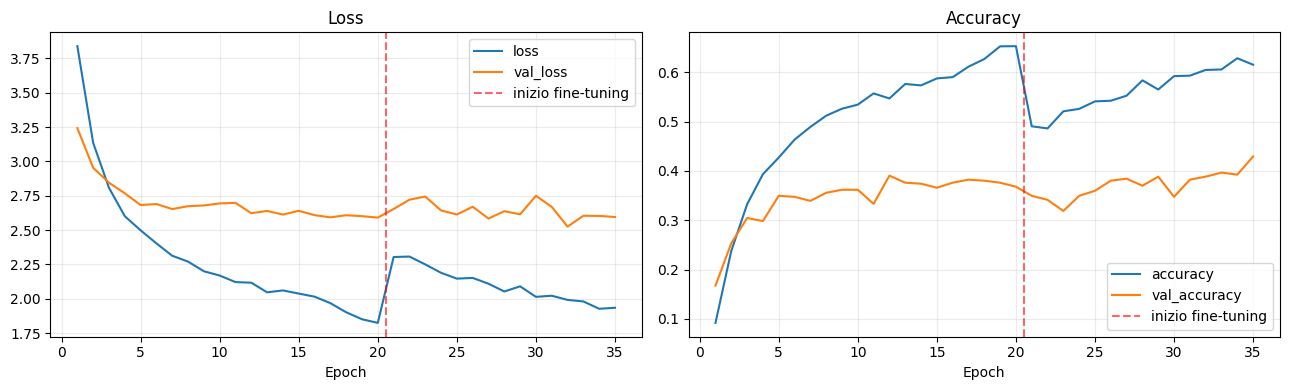

In [10]:
import csv as _csv

# Funzione per leggere la storia di training da un file CSV
def _read_history(path):
    rows = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
    with Path(path).open('r', encoding='utf-8', newline='') as fh:
        for row in _csv.DictReader(fh):
            for key in rows:
                rows[key].append(float(row.get(key, 0)))
    return rows


# Concateno le due fasi (se la Fase B esiste) per vedere la curva completa.
hist = _read_history(RUN_DIR / 'history.csv')
boundary = len(hist['loss'])   # epoca in cui inizia il fine-tuning
ft_path = RUN_DIR / 'history_finetune.csv'
if ft_path.exists():
    ft = _read_history(ft_path)
    for key in hist:
        hist[key].extend(ft[key])

# Visualizzo le curve di loss e accuracy (train/val) per tutte le epoche
epochs = range(1, len(hist['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, hist['loss'], label='loss')
axes[0].plot(epochs, hist['val_loss'], label='val_loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.25); axes[0].legend()
axes[1].plot(epochs, hist['accuracy'], label='accuracy')
axes[1].plot(epochs, hist['val_accuracy'], label='val_accuracy')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.25); axes[1].legend()
if ft_path.exists():
    for ax in axes:
        ax.axvline(boundary + 0.5, color='red', linestyle='--', alpha=0.6, label='inizio fine-tuning')
    axes[0].legend(); axes[1].legend()
fig.tight_layout()
fig.savefig(RUN_DIR / 'training_curves.png', dpi=160)
plt.show()


## 10. Valutazione sul test set

Carichiamo il miglior modello salvato e produciamo accuracy, macro precision, macro recall, macro F1, report per classe e matrice di confusione.


In [11]:
best_model_path = RUN_DIR / 'best_model.keras'
# compile=False: serve solo per inferenza, ed evita di dover deserializzare la loss custom (label smoothing). evaluate_to_dir usa solo model.predict.
best_model = tf.keras.models.load_model(best_model_path, compile=False)

# Valuto il modello sul dataset di test (non usato in training/val)
test_ds, test_count = make_dataset(
    TEST_MANIFEST,
    frame_count=FRAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    training=False,
    seed=SEED,
    limit_per_class=QUICK_LIMIT_PER_CLASS,
    cache=CACHE_DATASET,
)

# Eseguo l'inferenza sul dataset di test e salvo le metriche in RUN_DIR/test_eval
metrics_test = evaluate_to_dir(best_model, test_ds, class_names, RUN_DIR / 'test_eval')
print('Test records:', test_count)
print(json.dumps(metrics_test, indent=2))


Test records: 1511
{
  "accuracy": 0.41032428855062875,
  "macro_precision": 0.4197150421070602,
  "macro_recall": 0.40969589649707805,
  "macro_f1": 0.3952990444393143,
  "support": 1511.0
}


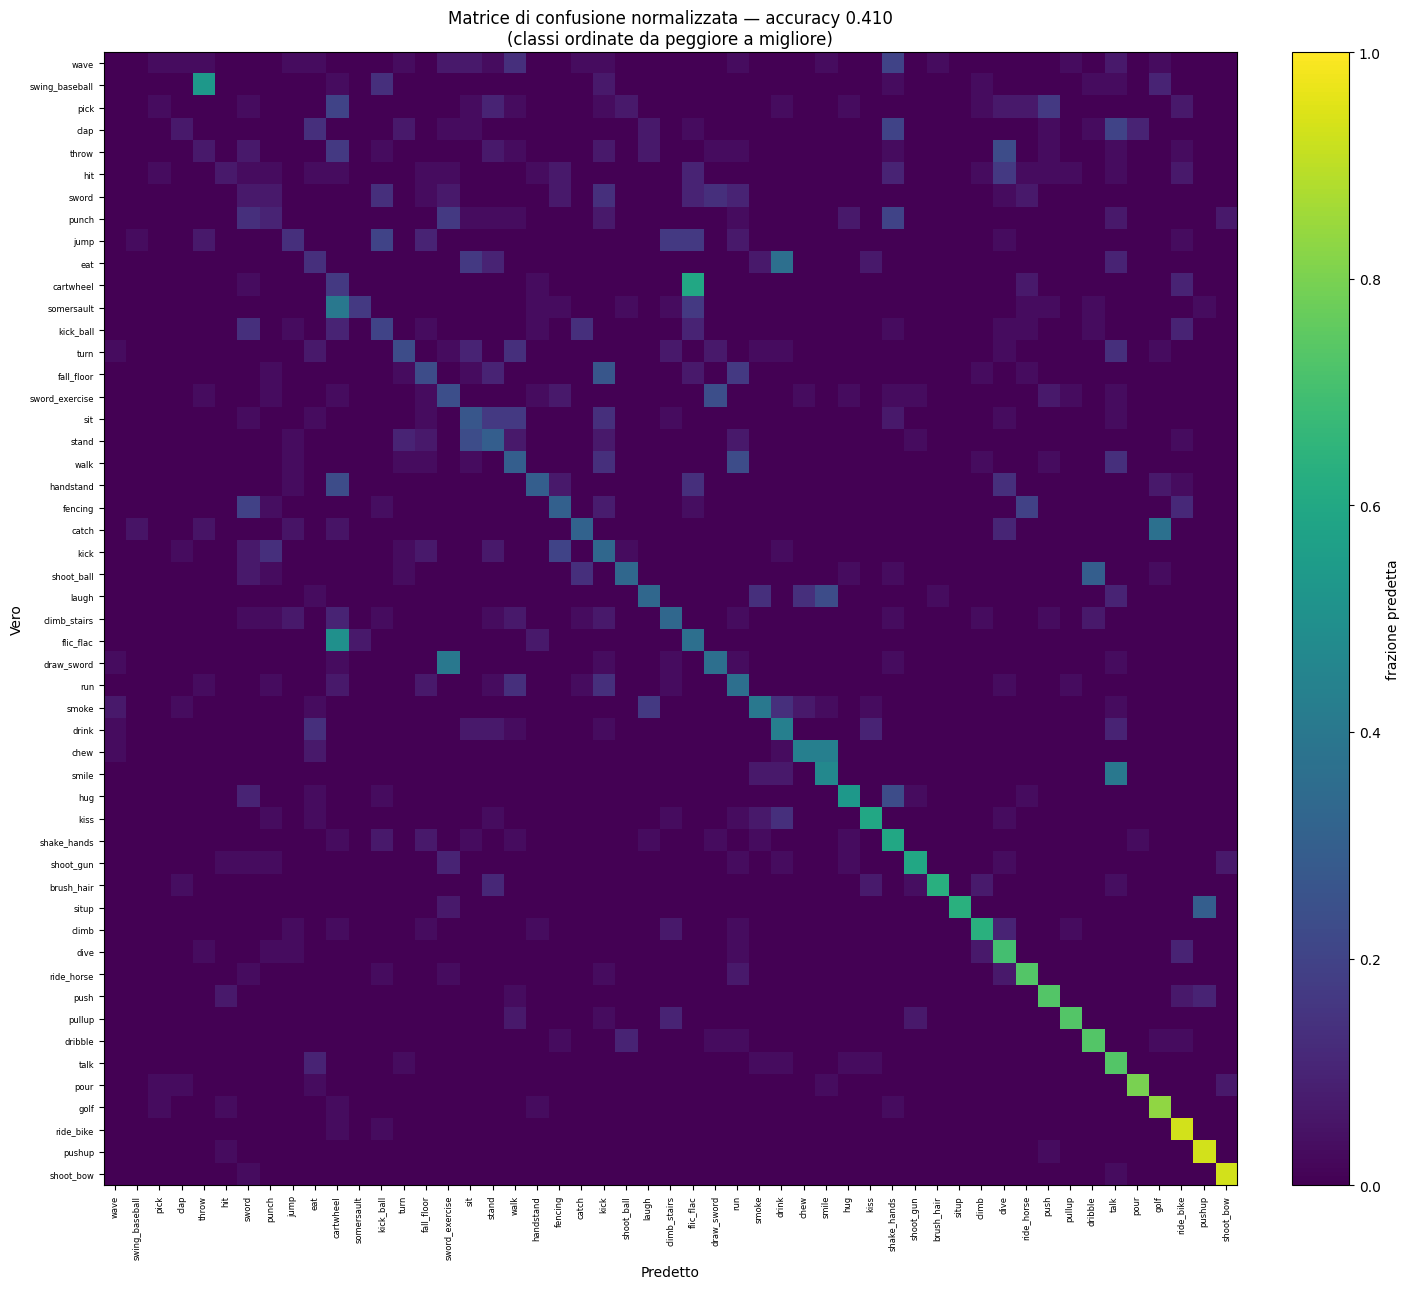

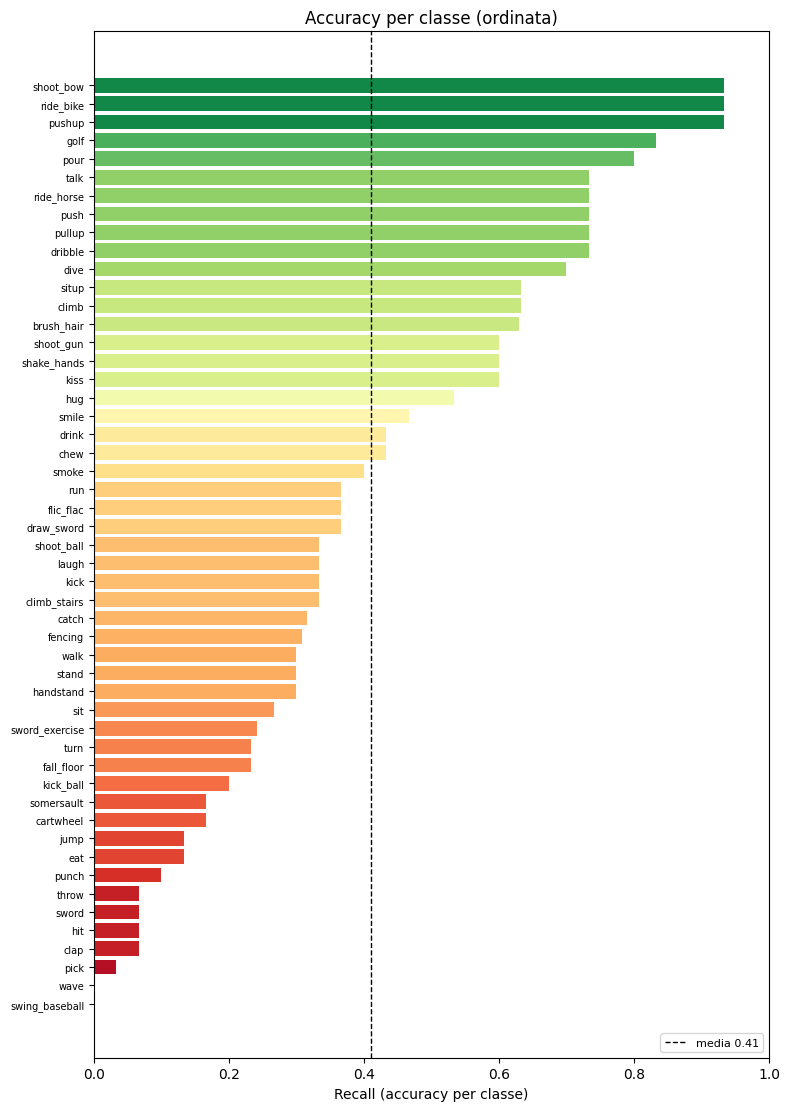

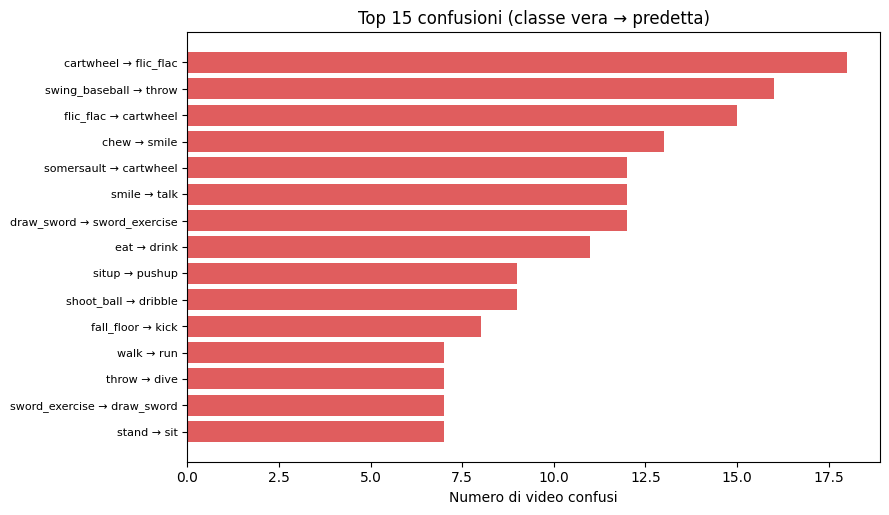


=== 3 classi PIU' FACILI da riconoscere ===
  shoot_bow      F1=0.87  precision=0.82  recall=0.93
  pour           F1=0.83  precision=0.86  recall=0.80
  pushup         F1=0.79  precision=0.68  recall=0.93

=== 3 classi PIU' DIFFICILI da riconoscere ===
  swing_baseball F1=0.00  precision=0.00  recall=0.00
  wave           F1=0.00  precision=0.00  recall=0.00
  pick           F1=0.06  precision=0.20  recall=0.03


In [13]:
eval_dir = RUN_DIR / 'test_eval'

# 1) Matrice di confusione normalizzata, classi ordinate da peggiore a migliore
plot_confusion_matrix(eval_dir / 'confusion_matrix.npy', class_names,
                      eval_dir / 'confusion_matrix_sorted.png')

"""
2) Accuracy per classe (ordinata): mostra a colpo d'occhio quali azioni
   riconosce (in alto, riconoscibili dall'aspetto) e quali no (in fondo,
   definite dal movimento) -> racconta il limite "appearance-based".
"""
plot_per_class_accuracy(eval_dir / 'classification_report.csv',
                        eval_dir / 'per_class_accuracy.png')

# 3) Le confusioni piu' frequenti (classe vera -> predetta): DOVE sbaglia.
plot_top_confusions(eval_dir / 'confusion_matrix.npy', class_names,
                    eval_dir / 'top_confusions.png', top_n=15)

# --- 3 classi migliori e 3 peggiori da riconoscere (per F1) ---
import csv as _csv
with (eval_dir / 'classification_report.csv').open() as _fh:
    _rows = sorted(_csv.DictReader(_fh), key=lambda r: float(r['f1']))

print('\n=== 3 classi PIU\' FACILI da riconoscere ===')
for r in reversed(_rows[-3:]):
    print(f"  {r['class_name']:<14} F1={float(r['f1']):.2f}  precision={float(r['precision']):.2f}  recall={float(r['recall']):.2f}")

print('\n=== 3 classi PIU\' DIFFICILI da riconoscere ===')
for r in _rows[:3]:
    print(f"  {r['class_name']:<14} F1={float(r['f1']):.2f}  precision={float(r['precision']):.2f}  recall={float(r['recall']):.2f}")


## 11. Predizione su un singolo video

Scegliere un file `.avi` e guarda le classi piu' probabili secondo il modello.


In [14]:
VIDEO_PATH = Path(test_records[0]['path'])
TOP_K = 5

video = decode_video(VIDEO_PATH, frame_count=FRAMES, image_size=IMAGE_SIZE)
probs = best_model.predict(np.expand_dims(video, axis=0), verbose=0)[0]
top_indices = np.argsort(probs)[::-1][:TOP_K]

print('Video:', VIDEO_PATH)
print('Classe vera:', test_records[0]['class_name'])
print('Predizioni:')
for rank, index in enumerate(top_indices, start=1):
    print(f'{rank}. {class_names[int(index)]}: {float(probs[int(index)]):.4f}')


Video: /Users/linshenhao/Desktop/Deep Learning /HMDB project/hmdb51/brush_hair/Aussie_Brunette_Brushing_Long_Hair_brush_hair_u_nm_np1_ba_med_3.avi
Classe vera: brush_hair
Predizioni:
1. brush_hair: 0.9447
2. pushup: 0.0075
3. shoot_gun: 0.0035
4. jump: 0.0035
5. wave: 0.0032
